# Introduction to APIs
### Fetching real-world data directly into Python

---

## What is an API?

So far in this course we always loaded data from a file sitting on our computer:

```python
df = pd.read_csv('data.csv')   # file on your hard drive
```

The problem: that file gets **stale**. If the data updates tomorrow, your file does not.

An **API (Application Programming Interface)** lets your code talk directly to a
server and pull **fresh data** every time you run it — no downloading, no manual updates.

```
Without API:   your code  →  local CSV  (frozen in time)
With API:      your code  →  internet  →  live server  →  fresh data
```

---

### How does an API call work?

When you type a URL in your browser, your browser sends a **request** to a server
and gets back a **response** (an HTML page).

An API works exactly the same way — but instead of HTML, the server sends back
**data** that Python can read directly.

```
Step 1  →  Python sends a GET request to a URL
Step 2  →  Server receives the request
Step 3  →  Server sends back data
Step 4  →  Python reads it into a DataFrame
```

---

### Three formats you will encounter

| Format | What it looks like | How to read it |
|--------|-------------------|----------------|
| **CSV** | Comma-separated table — same as a spreadsheet | `pd.read_csv(url)` |
| **JSON** | Nested key-value pairs — like a Python dictionary | `response.json()` + `pd.json_normalize()` |
| **API with parameters** | URL + filters you pass to narrow the data | `requests.get(url, params={...})` |

Today we cover all three — one real example each.

---

### The one library that handles all of them

```python
import requests
```

`requests` sends HTTP requests from Python — like a browser, but in code.
It works the same way for CSV, JSON, and parameterised APIs.

```python
response = requests.get(url)      # send the request
response.status_code              # did it work? 200 = yes
response.text                     # raw response as a string (for CSV)
response.json()                   # parse as JSON (for JSON APIs)
```

### Status codes — always check this first

| Code | Meaning |
|------|---------|
| 200 | ✅ Success |
| 400 | ❌ Bad request — something wrong with your URL or parameters |
| 401 | 🔑 Unauthorised — you need an API key |
| 404 | ❌ Not found — wrong URL |
| 500 | ❌ Server error — their problem, not yours |

In [23]:
!pip install requests

In [24]:
# ── Imports — run this first ──────────────────────────────────────────────────
import requests          # sends HTTP requests
import pandas as pd      # DataFrames
import io                # converts raw text into something pandas can read

print('Ready!')

Ready!


---
## Format 1 — CSV from a URL

### The concept

Some APIs return a plain CSV file at a URL — the simplest possible format.
You can even open it in your browser and see rows and columns.

There are two ways to load it:

```python
# Method A — pandas reads the URL directly (one line, hides everything)
df = pd.read_csv(url)

# Method B — requests then pandas (explicit, more control)
response = requests.get(url)
df = pd.read_csv(io.StringIO(response.text))
```

Both give the same result. Method B is better when you need to check the status
code, add headers, or handle errors before reading the data.

### `io.StringIO` — why do we need it?

`response.text` is a plain Python string — one giant block of text.
`pd.read_csv()` expects a **file**, not a string.
`io.StringIO()` wraps the string so pandas thinks it is reading a file.

```
response.text      →  'date,cases,deaths\n2020-01-01,0,0\n...'  (just a string)
io.StringIO(...)   →  pretends to be a file object
pd.read_csv(...)   →  reads it as a proper DataFrame
```

### Real example — COVID-19 data (Our World in Data)

Our World in Data publishes a CSV updated daily on GitHub.
Every time we run this cell we get the latest numbers.

In [25]:
# ── Method A — simplest ───────────────────────────────────────────────────────
url_covid = 'https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv'

df_covid = pd.read_csv(url_covid)
print(f'Shape: {df_covid.shape}')
df_covid.head(3)

Shape: (429435, 67)


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [26]:
# ── Method B — explicit request ───────────────────────────────────────────────
# Same result, but now we can inspect what happened before loading

response = requests.get(url_covid)

# Always check status first
print(f'Status code : {response.status_code}')       # 200 = OK
print(f'Content type: {response.headers["Content-Type"]}')
print(f'Response size: {len(response.text):,} characters')
print()

# Show what the raw text looks like before pandas reads it
print('First 300 characters of raw response:')
print(response.text[:300])

Status code : 200
Content type: text/plain; charset=utf-8
Response size: 98,391,483 characters

First 300 characters of raw response:
iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths_per_million,new_deaths_per_million,new_deaths_smoothed_per_million,reproduction_rate,icu_pat


In [27]:
# ── Now convert to DataFrame ──────────────────────────────────────────────────
# io.StringIO wraps the string so pd.read_csv can treat it like a file

df_covid = pd.read_csv(io.StringIO(response.text))

print(f'Rows    : {df_covid.shape[0]:,}')
print(f'Columns : {df_covid.shape[1]}')
print(f'Countries: {df_covid["location"].nunique()}')
print(f'Date range: {df_covid["date"].min()}  →  {df_covid["date"].max()}')

Rows    : 429,435
Columns : 67
Countries: 255
Date range: 2020-01-01  →  2024-08-14


### Exercise 1 — CSV from a URL

OWID publishes many datasets as direct CSV URLs.
Try loading the **life expectancy** dataset using both methods.

In [ ]:
url_life = 'https://ourworldindata.org/grapher/life-expectancy.csv'

# Q1: Load using Method A (one line)
df_life = pd.read_csv(___)

# Q2: What are the column names?
print(df_life.___)   # hint: .columns.tolist()

# Q3: How many unique countries are in this dataset?
print(df_life[___].nunique())

# Q4: Load using Method B — check the status code before reading
response_life = requests.get(___)
print(f'Status: {response_life.___}')
df_life_b = pd.read_csv(io.StringIO(response_life.text))
print(df_life_b.shape)

# ANSWERS:
# Q1: pd.read_csv(url_life)
# Q2: df_life.columns.tolist()
# Q3: df_life['Entity'].nunique()   ← OWID uses 'Entity' not 'location'
# Q4: requests.get(url_life) / response_life.status_code

---
## Format 2 — JSON API

### The concept

Many APIs return **JSON** instead of CSV. JSON is not a table — it is a nested
structure of keys and values, like a Python dictionary.

```json
{
  "name": "Brazil",
  "population": 215313498,
  "languages": {"por": "Portuguese"},
  "area": 8515767.0
}
```

The challenge: JSON can be deeply nested. A country might have a list of languages,
each with sub-fields. You cannot just `pd.read_csv()` this.

### How to handle JSON

```python
response = requests.get(url)

# Step 1: parse JSON into a Python list/dict
data = response.json()

# Step 2: flatten nested structure into a DataFrame
df = pd.json_normalize(data)
```

`pd.json_normalize()` is the key function — it takes a nested JSON structure
and flattens it into rows and columns. Nested keys become column names like
`languages.por` or `flags.svg`.

### Real example — REST Countries API

Returns information about every country in the world — population, area,
languages, currencies, flags — all in JSON, no key needed.

In [28]:
# ── Fetch the JSON response ───────────────────────────────────────────────────
# JSONPlaceholder — the most reliable free JSON API for learning
# Returns fake but realistic user data — no key, no sign-up, never goes down

url_users = 'https://jsonplaceholder.typicode.com/users'

response = requests.get(url_users)
print(f'Status: {response.status_code}')   # should be 200

data = response.json()
print(f'Type    : {type(data)}')           # list
print(f'Users   : {len(data)}')            # 10 users

Status: 200
Type    : <class 'list'>
Users   : 10


In [29]:
# ── Inspect ONE user before flattening ───────────────────────────────────────
import json

# data is a list — each item is one user dict
print(f'Type of first item: {type(data[0])}')
print()
print(json.dumps(data[0], indent=2))

Type of first item: <class 'dict'>

{
  "id": 1,
  "name": "Leanne Graham",
  "username": "Bret",
  "email": "Sincere@april.biz",
  "address": {
    "street": "Kulas Light",
    "suite": "Apt. 556",
    "city": "Gwenborough",
    "zipcode": "92998-3874",
    "geo": {
      "lat": "-37.3159",
      "lng": "81.1496"
    }
  },
  "phone": "1-770-736-8031 x56442",
  "website": "hildegard.org",
  "company": {
    "name": "Romaguera-Crona",
    "catchPhrase": "Multi-layered client-server neural-net",
    "bs": "harness real-time e-markets"
  }
}


In [30]:
# ── Flatten into a DataFrame ──────────────────────────────────────────────────
df_users = pd.json_normalize(data)

print(df_users.columns.tolist())
print()
df_users[['name', 'email', 'address.city', 'company.name']]

['id', 'name', 'username', 'email', 'phone', 'website', 'address.street', 'address.suite', 'address.city', 'address.zipcode', 'address.geo.lat', 'address.geo.lng', 'company.name', 'company.catchPhrase', 'company.bs']



,name,email,address.city,company.name
0,Leanne Graham,Sincere@april.biz,Gwenborough,Romaguera-Crona
1,Ervin Howell,Shanna@melissa.tv,Wisokyburgh,Deckow-Crist
2,Clementine Bauch,Nathan@yesenia.net,McKenziehaven,Romaguera-Jacobson
3,Patricia Lebsack,Julianne.OConner@kory.org,South Elvis,Robel-Corkery
4,Chelsey Dietrich,Lucio_Hettinger@annie.ca,Roscoeview,Keebler LLC
5,Mrs. Dennis Schulist,Karley_Dach@jasper.info,South Christy,Considine-Lockman
6,Kurtis Weissnat,Telly.Hoeger@billy.biz,Howemouth,Johns Group
7,Nicholas Runolfsdottir V,Sherwood@rosamond.me,Aliyaview,Abernathy Group
8,Glenna Reichert,Chaim_McDermott@dana.io,Bartholomebury,Yost and Sons
9,Clementina DuBuque,Rey.Padberg@karina.biz,Lebsackbury,Hoeger LLC


In [31]:
# ── Select useful columns ─────────────────────────────────────────────────────
# After flattening you usually pick just the columns you need
# Nested keys use dot notation: 'address.city', 'company.name'

df_clean = df_users[[
    'name',           # full name
    'email',          # email
    'address.city',   # city (nested under address)
    'company.name',   # company (nested under company)
    'website',        # website
]].copy()

# Rename for convenience
df_clean.columns = ['name', 'email', 'city', 'company', 'website']

print('Users DataFrame:')
print(df_clean.to_string(index=False))

Users DataFrame:
                    name                     email           city            company       website
           Leanne Graham         Sincere@april.biz    Gwenborough    Romaguera-Crona hildegard.org
            Ervin Howell         Shanna@melissa.tv    Wisokyburgh       Deckow-Crist anastasia.net
        Clementine Bauch        Nathan@yesenia.net  McKenziehaven Romaguera-Jacobson   ramiro.info
        Patricia Lebsack Julianne.OConner@kory.org    South Elvis      Robel-Corkery      kale.biz
        Chelsey Dietrich  Lucio_Hettinger@annie.ca     Roscoeview        Keebler LLC  demarco.info
    Mrs. Dennis Schulist   Karley_Dach@jasper.info  South Christy  Considine-Lockman       ola.org
         Kurtis Weissnat    Telly.Hoeger@billy.biz      Howemouth        Johns Group      elvis.io
Nicholas Runolfsdottir V      Sherwood@rosamond.me      Aliyaview    Abernathy Group  jacynthe.com
         Glenna Reichert   Chaim_McDermott@dana.io Bartholomebury      Yost and Sons    conr

In [32]:
# See ALL columns available after flattening
print(df_users.columns.tolist())

['id', 'name', 'username', 'email', 'phone', 'website', 'address.street', 'address.suite', 'address.city', 'address.zipcode', 'address.geo.lat', 'address.geo.lng', 'company.name', 'company.catchPhrase', 'company.bs']


### Exercise 2 — JSON API

In [33]:
# REST Countries also lets you search by region:
# https://restcountries.com/v3.1/region/europe
# https://restcountries.com/v3.1/region/asia
# https://restcountries.com/v3.1/region/africa

# Q1: Fetch only European countries
url_europe = 'https://restcountries.com/v3.1/region/___'   # fill in
response_eu = requests.get(___)
print(f'Status: {response_eu.___}')

# Q2: Parse JSON and flatten into a DataFrame
data_eu = response_eu.___()          # hint: .json()
df_eu   = pd.json_normalize(___)
print(f'European countries: {len(df_eu)}')

# Q3: Show name and population of the top 5 most populous European countries
df_eu_clean = df_eu[['name.common', 'population']].copy()
df_eu_clean.columns = ['country', 'population']
print(df_eu_clean.sort_values('population', ascending=___).head(5).to_string(index=False))

# ANSWERS:
# Q1: url = '...region/europe',  requests.get(url_europe),  .status_code
# Q2: response_eu.json(),  pd.json_normalize(data_eu)
# Q3: ascending=False

MissingSchema: Invalid URL 'name                      email    address.city  \\\n0             Leanne Graham          Sincere@april.biz     Gwenborough   \n1              Ervin Howell          Shanna@melissa.tv     Wisokyburgh   \n2          Clementine Bauch         Nathan@yesenia.net   McKenziehaven   \n3          Patricia Lebsack  Julianne.OConner@kory.org     South Elvis   \n4          Chelsey Dietrich   Lucio_Hettinger@annie.ca      Roscoeview   \n5      Mrs. Dennis Schulist    Karley_Dach@jasper.info   South Christy   \n6           Kurtis Weissnat     Telly.Hoeger@billy.biz       Howemouth   \n7  Nicholas Runolfsdottir V       Sherwood@rosamond.me       Aliyaview   \n8           Glenna Reichert    Chaim_McDermott@dana.io  Bartholomebury   \n9        Clementina DuBuque     Rey.Padberg@karina.biz     Lebsackbury   \n\n         company.name  \n0     Romaguera-Crona  \n1        Deckow-Crist  \n2  Romaguera-Jacobson  \n3       Robel-Corkery  \n4         Keebler LLC  \n5   Considine-Loc

---
## Format 3 — API with parameters

### The concept

Many APIs let you filter or customise the data you receive by passing
**parameters** in the request — instead of downloading everything and filtering locally,
you tell the server exactly what you want.

Parameters are added to the URL after a `?`, separated by `&`:

```
https://api.example.com/data?country=Brazil&year=2020&format=csv
                              └─────────────────────────────────┘
                                        parameters
```

With `requests`, you never build this URL manually — you pass a dictionary:

```python
params = {
    'country': 'Brazil',
    'year': 2020,
    'format': 'csv'
}
response = requests.get(url, params=params)
# requests builds the full URL for you automatically
```

This is cleaner, safer, and handles special characters automatically.

### Real example — OWID Chart API

Every chart on ourworldindata.org has a data URL.
Just add `.csv` to any chart URL to get the raw data.
You can then pass parameters to filter by country and time range.

In [34]:
# ── See how requests builds the URL from params ───────────────────────────────
# Before making the real call, let's see what URL gets constructed

base_url = 'https://ourworldindata.org/grapher/life-expectancy.csv'

params = {
    'csvType'  : 'filtered',     # ask for filtered data, not everything
    'country'  : 'BRA~DEU~USA',  # country codes separated by ~
    'time'     : '1950..2023'    # year range with ..
}

# requests.Request builds the URL without sending it
# useful for debugging — you can see exactly what will be sent
prepared = requests.Request('GET', base_url, params=params).prepare()
print('Full URL that will be sent:')
print(prepared.url)

Full URL that will be sent:
https://ourworldindata.org/grapher/life-expectancy.csv?csvType=filtered&country=BRA~DEU~USA&time=1950..2023


In [35]:
# ── Now make the real request ─────────────────────────────────────────────────
response = requests.get(base_url, params=params)

print(f'Status: {response.status_code}')
print(f'Size  : {len(response.text):,} characters')
print()
print('Raw response (first 400 chars):')
print(response.text[:400])

Status: 200
Size  : 5,927 characters

Raw response (first 400 chars):
Entity,Code,Year,Life expectancy
Brazil,BRA,1950,48.5286
Brazil,BRA,1951,49.0447
Brazil,BRA,1952,49.5531
Brazil,BRA,1953,49.9883
Brazil,BRA,1954,50.4339
Brazil,BRA,1955,50.8866
Brazil,BRA,1956,51.3433
Brazil,BRA,1957,51.8056
Brazil,BRA,1958,52.2487
Brazil,BRA,1959,52.7043
Brazil,BRA,1960,53.1624
Brazil,BRA,1961,53.5944
Brazil,BRA,1962,54.0165
Brazil,BRA,1963,54.4516
Brazil,BRA,1964,54.8483
Brazil,


In [36]:
# ── Load into DataFrame ───────────────────────────────────────────────────────
df_life = pd.read_csv(io.StringIO(response.text))

print(df_life.columns.tolist())
print(f'Rows: {len(df_life)}')
print()
df_life.head()

['Entity', 'Code', 'Year', 'Life expectancy']
Rows: 222



,Entity,Code,Year,Life expectancy
0,Brazil,BRA,1950,48.5286
1,Brazil,BRA,1951,49.0447
2,Brazil,BRA,1952,49.5531
3,Brazil,BRA,1953,49.9883
4,Brazil,BRA,1954,50.4339


In [39]:
print(df_life.columns.tolist())

['Entity', 'Code', 'Year', 'Life expectancy']


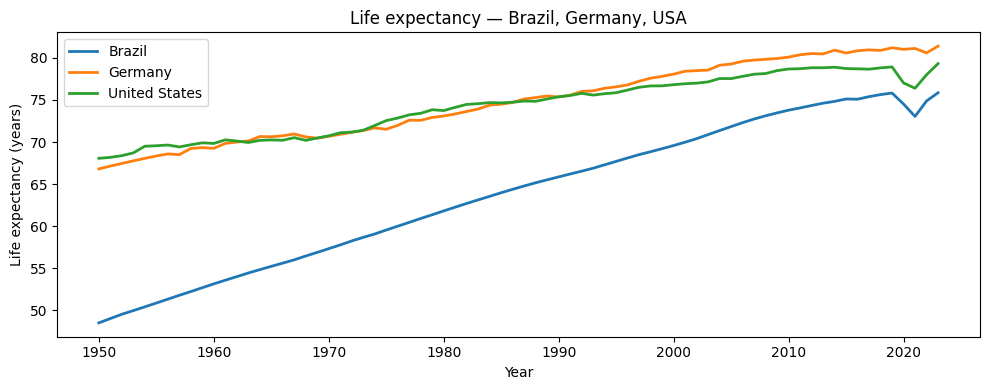

In [40]:
# ── Plot ─────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

value_col = 'Life expectancy'

# Filter each country into its own variable
df_brazil  = df_life[df_life['Entity'] == 'Brazil']
df_germany = df_life[df_life['Entity'] == 'Germany']
df_usa     = df_life[df_life['Entity'] == 'United States']

# Plot each one separately
plt.figure(figsize=(10, 4))
plt.plot(df_brazil['Year'],  df_brazil[value_col],  linewidth=2, label='Brazil')
plt.plot(df_germany['Year'], df_germany[value_col], linewidth=2, label='Germany')
plt.plot(df_usa['Year'],     df_usa[value_col],     linewidth=2, label='United States')

plt.xlabel('Year')
plt.ylabel('Life expectancy (years)')
plt.title('Life expectancy — Brazil, Germany, USA')
plt.legend()
plt.tight_layout()
plt.show()

---
## APIs worth exploring on your own

### No sign-up required — try these right now

| Dataset | URL | Format | What you get |
|---------|-----|--------|-------------|
| **COVID-19** | `https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv` | CSV | Cases, deaths, vaccinations |
| **OWID Life expectancy** | `https://ourworldindata.org/grapher/life-expectancy.csv` | CSV + params | Life expectancy by country |
| **OWID CO₂** | `https://ourworldindata.org/grapher/annual-co2-emissions-per-country.csv` | CSV + params | CO₂ emissions by country |
| **OWID Population** | `https://ourworldindata.org/grapher/population.csv` | CSV + params | Population since 10,000 BCE |
| **REST Countries** | `https://restcountries.com/v3.1/all` | JSON | Country info, population, area |
| **Open Meteo** | `https://api.open-meteo.com/v1/forecast?latitude=52.52&longitude=13.41&daily=temperature_2m_max` | JSON | Weather forecast for any coordinates |
| **NASA APOD** | `https://api.nasa.gov/planetary/apod?api_key=DEMO_KEY` | JSON | Astronomy picture of the day |
| **CoinGecko** | `https://api.coingecko.com/api/v3/coins/bitcoin/market_chart?vs_currency=usd&days=30` | JSON | Bitcoin price last 30 days |

### OWID chart API — find any dataset

Every chart on ourworldindata.org becomes a data URL:

```
Chart page:  https://ourworldindata.org/grapher/SLUG
Data (CSV):  https://ourworldindata.org/grapher/SLUG.csv
```

Go to https://ourworldindata.org/data, find any topic, copy the slug from the URL.

### Require a free API key

| Dataset | Website | What you get |
|---------|---------|-------------|
| **OpenWeather** | openweathermap.org/api | Live weather for any city |
| **Alpha Vantage** | alphavantage.co | Stock prices, forex, crypto |
| **NewsAPI** | newsapi.org | Headlines from 80,000 sources |
| **Spotify** | developer.spotify.com | Songs, audio features, playlists |
| **World Bank** | datahelpdesk.worldbank.org | GDP, poverty, development indicators |

---
## Quick Reference

```python
import requests, pandas as pd, io

# ── Format 1: CSV from URL ────────────────────────────────────────────────────
df = pd.read_csv('https://server.com/data.csv')           # Method A — simplest

response = requests.get('https://server.com/data.csv')    # Method B — explicit
print(response.status_code)                               # always check: 200 = OK
df = pd.read_csv(io.StringIO(response.text))              # string → file → DataFrame

# ── Format 2: JSON API ────────────────────────────────────────────────────────
response = requests.get('https://api.server.com/data')
data = response.json()                # parse JSON → Python list/dict
df   = pd.json_normalize(data)        # flatten nested structure → DataFrame

# ── Format 3: API with parameters ────────────────────────────────────────────
params = {
    'country': 'Brazil',
    'year'   : 2020
}
response = requests.get(url, params=params)   # requests builds the URL for you

# See the full URL that was built (useful for debugging)
prepared = requests.Request('GET', url, params=params).prepare()
print(prepared.url)

# ── Status codes ─────────────────────────────────────────────────────────────
# 200 = OK
# 400 = bad request  (wrong params)
# 401 = unauthorised (need API key)
# 404 = not found    (wrong URL)
# 500 = server error (their problem)

# ── OWID Chart API pattern ────────────────────────────────────────────────────
# Any chart on ourworldindata.org → append .csv for data
# https://ourworldindata.org/grapher/SLUG.csv
# params: csvType='filtered', country='BRA~DEU', time='1990..2020'
```